# Comparing Local Explanations

We focus on tabular data for regression.
- Local ALE (my contribution)
- LIME
- Ceteris Paribus Plots
- Counterfactuals

We implement all explainers ourselves.
- The Ceteris Paribus plot is self-explanatory, and is also known as an Individual Conditional Expectation (ICE) plot.
- We convert the implementation for LIME, which is originally for classificaiton, to a version for regression. We adapted from the LIME repository: [LIME Python implementation](https://github.com/marcotcr/lime/tree/ce2db6f20f47c3330beb107bb17fd25840ca4606).
- We implement permutation sampling for Shapley values, which is the standard sampling method used in practice. We also implement a version that uses antithetic variates.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from tqdm.auto import tqdm

from cp import CeterisParibus
from ale import ALE
from lime import LIME
from shap import SHAP

from utils import bin_selection

/Users/dawsonren/miniconda3/envs/ml/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
run_example_1 = False
run_example_2 = False
run_example_3 = False
run_example_4 = False
run_example_5 = True

In [3]:
# generate data
def generate_2d_data(n, sigma=0.05):
    Z = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    epsilon = np.random.normal(0, sigma, n)
    X1 = Z
    X2 = Z + epsilon

    return np.vstack([X1, X2]).T

def generate_independent_2d_data(n):
    X1 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    X2 = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    return np.vstack([X1, X2]).T

def generate_2d_data_normal(n, rho=0.5):
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]  # covariance matrix
    data = np.random.multivariate_normal(mean, cov, n)
    return data

def generate_3d_data(n, sigma=0.05):
    Z = np.random.uniform(1, 2, n)
    epsilon_1 = np.random.normal(0, sigma, n)
    epsilon_2 = np.random.normal(0, sigma, n)
    epsilon_3 = np.random.normal(0, sigma, n)
    X1 = Z + epsilon_1
    X2 = Z + epsilon_2
    X3 = Z + epsilon_3
    return np.vstack([X1, X2, X3]).T

def generate_mixed_data(n, num_categories=3):
    x1 = np.random.randint(0, num_categories, n)
    x2 = np.random.uniform(0, 1, n)
    return np.vstack([x1, x2]).T

In [4]:
def plot_learned_surface(dgp, f_factory, n=1000, K=20):
    X, y = dgp(n)
    f = f_factory(X, y)
    y_pred = f(X)
    
    # plot 3d surface
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], y_pred, c='r', marker='o')
    # plot surface of y_pred
    x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), K)
    x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), K)
    x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
    y_grid = f(np.c_[x1_grid.ravel(), x2_grid.ravel()])
    y_grid = y_grid.reshape(x1_grid.shape)
    ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('f(X)')
    plt.show()

In [5]:
x_explain = np.array([1, 1])
f = lambda x: x[:, 0] + x[:, 1] ** 2
n = 100
X = generate_2d_data_normal(n, rho=0.8)
X[0, :] = x_explain
y = f(X)
bins = bin_selection(n)

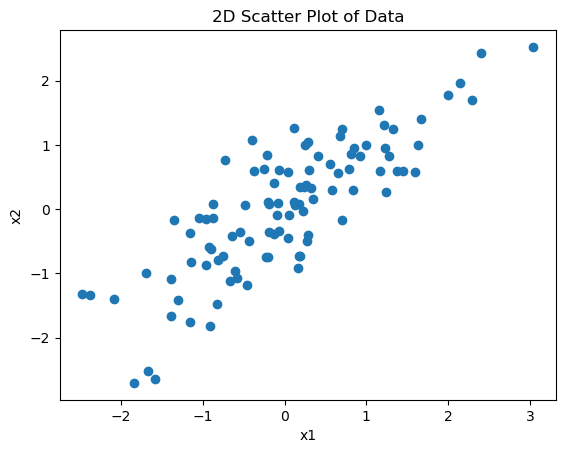

In [6]:
# 2d scatter plot
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Scatter Plot of Data")
plt.show()

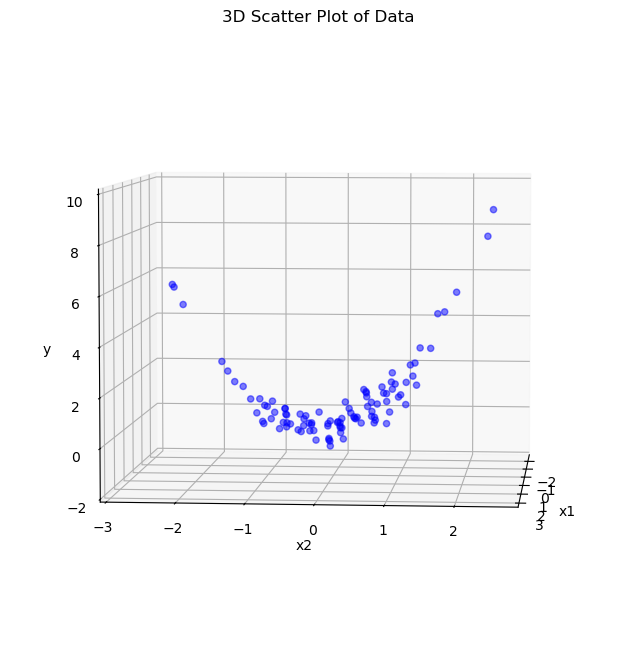

In [7]:
# 3d scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(5, 5)
ax.scatter(X[:, 0], X[:, 1], y, c='blue', marker='o', alpha=0.5)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Scatter Plot of Data')
plt.show()

Feature | Value
-------------------
X1 | [1.]
X2 | [1.]
-------------------
Prediction: 2.0


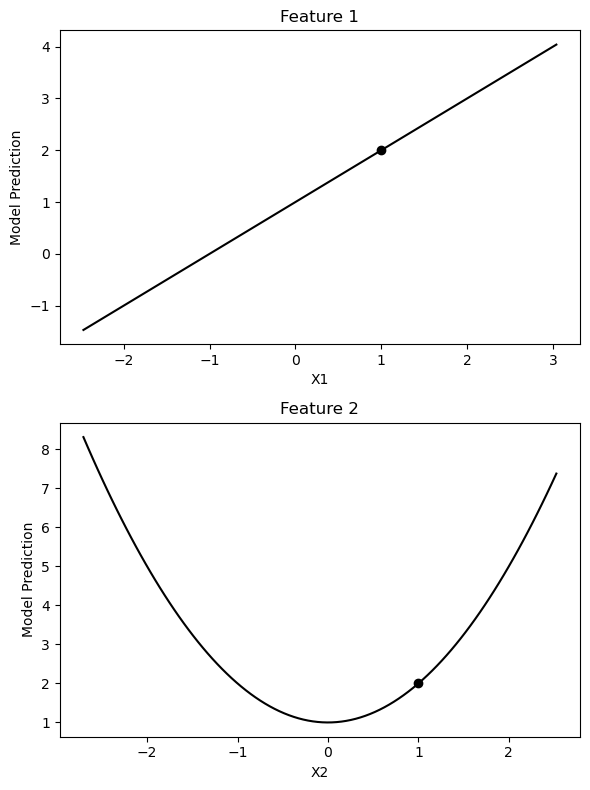

In [8]:
cp = CeterisParibus(f, X, bins=100)
cp.explain_local(0)

In [9]:
def plot_queried_points(X, query_points):
    plt.scatter(X[:, 0], X[:, 1], marker='o', label='Data Points', alpha=0.5)
    plt.scatter(query_points[:, 0], query_points[:, 1], marker='x', color='red', label='Queried Points')
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title(f"Queried Points by Explanation (q: {len(query_points)}, n: {X.shape[0]})")
    plt.legend()
    plt.show()

## Visualizing Queried Points

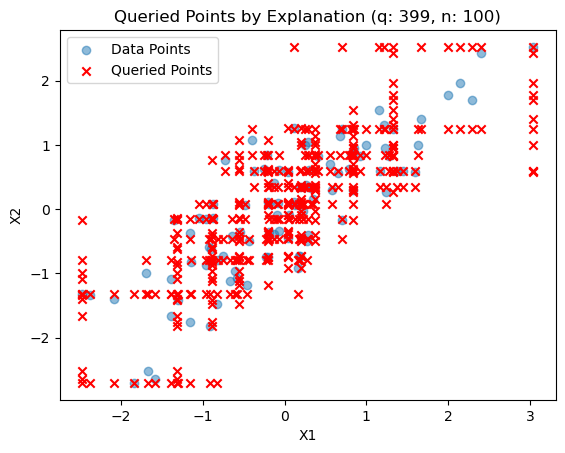

In [10]:
ale = ALE(f=f, X=X, bins=bins, verbose=False)
ale.explain()
ale.explain_local(x_explain)
plot_queried_points(X, ale.get_query_points())

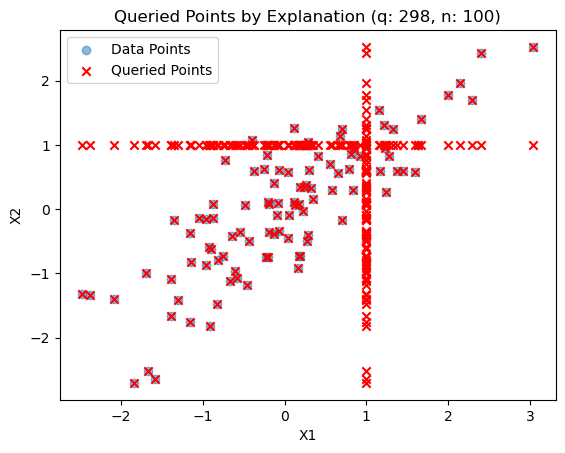

In [11]:
shap = SHAP(f, X, verbose=False)
shap.explain_local(x_explain, num_samples=1000)
plot_queried_points(X, shap.get_query_points())

In [12]:
def replicate_compared_local_explanations(dgp, f_factory, x_explain, n=200, m=50, config=None):
    default_config = {
        "bins": bin_selection(n),
        "kernel_width": None,
        "lime_samples": 5000,
        "shap_samples": 100,
        "relevant_features": x_explain.size,
        "ale_interpolate": False,
        "ale_local_method": "tree",
        "verbose": True,
        "seed": 42
    }
    if config is None:
        config = default_config
    config = default_config | config

    ale_local_explanations = []
    lime_local_explanations = []
    shap_local_explanations = []

    np.random.seed(config["seed"])
    data = [dgp(n) for _ in range(m)]

    lime_begin = time.perf_counter()
    # LIME
    for X, y in data:
        f = f_factory(X, y)
        lime_explaination = LIME(f, X, verbose=False, kernel_width=config["kernel_width"])
        lime_local_exp = lime_explaination.explain_local(x_explain, relevant_features=config["relevant_features"], num_samples=config["lime_samples"])
        # convert dictionary to array
        lime_local_exp_array = np.array([lime_local_exp[feature] for feature in lime_local_exp.keys()])
        lime_local_explanations.append(lime_local_exp_array)
    lime_end = time.perf_counter()
    lime_time = lime_end - lime_begin

    # ALE
    ale_begin = time.perf_counter()
    for X, y in data:
        f = f_factory(X, y)
        ale_explaination = ALE(f, X, bins=config["bins"], verbose=False, interpolate=config["ale_interpolate"])
        ale_explaination.explain()
        ale_local_exp = ale_explaination.explain_local(x_explain, method=config["ale_local_method"])

        # convert dictionary to array
        ale_local_exp_array = np.array([ale_local_exp[feature] for feature in ale_local_exp.keys()])
        ale_local_explanations.append(ale_local_exp_array)
    ale_end = time.perf_counter()
    ale_time = ale_end - ale_begin

    # SHAP
    shap_begin = time.perf_counter()
    for X, y in data:
        f = f_factory(X, y)
        shap_explaination = SHAP(f, X, verbose=False)
        shap_local_exp = shap_explaination.explain_local(x_explain, num_samples=config["shap_samples"])

        # convert dictionary to array
        shap_local_exp_array = np.array([shap_local_exp[feature] for feature in shap_local_exp.keys()])
        shap_local_explanations.append(shap_local_exp_array)

    shap_end = time.perf_counter()
    shap_time = shap_end - shap_begin

    # print table of average time / replication
    if config["verbose"]:
        print(f"Average LIME time: {lime_time / m:.4f}s")
        print(f"Average ALE time: {ale_time / m:.4f}s")
        print(f"Average SHAP time: {shap_time / m:.4f}s")

    return np.array(ale_local_explanations), np.array(lime_local_explanations), np.array(shap_local_explanations)

In [13]:
def plot_replicated_local_explanations(replications, x_explain, method):
    # get colors
    colors = plt.cm.viridis(np.linspace(0, 1, replications.shape[1]))
    for i in range(replications.shape[1]):
        plt.hist(replications[:, i], bins=20, alpha=0.5, label=f'Feature {i+1}', color=colors[i])
        # plot means
        plt.axvline(np.mean(replications[:, i]), color=colors[i], linestyle='dashed', linewidth=1, label='Mean')

    plt.xlabel('Local Explanation Value')
    plt.ylabel('Frequency')
    plt.title(f'{method} Local Explanation at {x_explain}')
    plt.legend()
    plt.show()

In [14]:
def plot_estimator_consistency(dgp, f_factory, x_explain, m=50, config=None):
    n = np.array([100, 200, 500, 1000, 2000, 5000, 10000])
    ale_means = np.zeros((n.size, x_explain.size))
    lime_means = np.zeros((n.size, x_explain.size))
    shap_means = np.zeros((n.size, x_explain.size))
    ale_stds = np.zeros((n.size, x_explain.size))
    lime_stds = np.zeros((n.size, x_explain.size))
    shap_stds = np.zeros((n.size, x_explain.size))

    for i, n_value in tqdm(enumerate(n)):
        ale_replications, lime_replications, shap_replications = replicate_compared_local_explanations(dgp, f_factory, x_explain, n=n_value, m=m, config=config)
        ale_means[i, :] = np.mean(ale_replications, axis=0)
        lime_means[i, :] = np.mean(lime_replications, axis=0)
        shap_means[i, :] = np.mean(shap_replications, axis=0)
        ale_stds[i, :] = np.std(ale_replications, axis=0)
        lime_stds[i, :] = np.std(lime_replications, axis=0)
        shap_stds[i, :] = np.std(shap_replications, axis=0)

    # plot means with errors in line graph
    for i in range(x_explain.size):
        plt.errorbar(n, ale_means[:, i], yerr=ale_stds[:, i], label=f'ALE Feature {i + 1}', marker='o')
        # plt.errorbar(n, lime_means[:, i], yerr=lime_stds[:, i], label=f'LIME Feature {i + 1}', marker='o')
        plt.errorbar(n, shap_means[:, i], yerr=shap_stds[:, i], label=f'SHAP Feature {i + 1}', marker='o')
    plt.xscale('log')
    plt.xlabel('Sample Size (n)')
    plt.ylabel('Mean Local Explanation Value')
    plt.title(f'Estimator Consistency at {x_explain} (replications={m})')
    plt.legend()
    plt.show()

In [15]:
config = {
    "shap_samples": 1000,
    "ale_interpolate": True,
    "force_x_explain_in_dataset": False,
    "shap_antithetic": False
}
consistency_config = {
    "shap_samples": 100,
    "ale_interpolate": True,
    "force_x_explain_in_dataset": False,
    "shap_antithetic": False,
    "verbose": False
}

## Example 1
Uniform DGP with Exact Model

In [16]:
if run_example_1:
    f = lambda x: x[:, 0] + x[:, 1] ** 2
    def example_1_dgp(n):
        u = np.random.uniform(0, 1, n)
        x1 = u + np.random.normal(0, 0.1, n)
        x2 = u + np.random.normal(0, 0.1, n)
        X = np.column_stack((x1, x2))
        return X, f(X)
    example_1_f_factory = lambda X, y: f
    x_explain = np.array([0, 0])

In [17]:
if run_example_1:
    ale_replications, lime_replications, shap_replications = replicate_compared_local_explanations(example_1_dgp, example_1_f_factory, x_explain, n=100, m=100, config=config)

In [18]:
if run_example_1:
    plot_replicated_local_explanations(ale_replications, x_explain, method="ALE")

In [19]:
if run_example_1:
    plot_replicated_local_explanations(shap_replications, x_explain, method="SHAP")

### Consistency of Estimator

In [20]:
if run_example_1:
    plot_estimator_consistency(example_1_dgp, example_1_f_factory, np.array([1, 1]), m=10, config=consistency_config)

## Example 2
Uniform DGP with NN Model (Example 5 from ALE VIM Manuscript)

In [21]:
if run_example_2:
    def example_2_dgp(n):
        u = np.random.uniform(0, 1, n)
        x1 = u + np.random.normal(0, 0.1, n)
        x2 = u + np.random.normal(0, 0.1, n)
        X = np.column_stack((x1, x2))
        y = x1 + x2 ** 2 + np.random.normal(0, 0.1, n)
        return X, y

    def example_2_f_factory(X, y):
        # train a neural network regressor
        mlp = MLPRegressor(
            hidden_layer_sizes=(80,),
            activation='relu',
            solver='adam',
            alpha=0.00001,
            learning_rate='constant',
            max_iter=1000,
            random_state=42
        )
        mlp.fit(X, y)
        return lambda X: mlp.predict(X)

    x_explain = np.array([1, 1])

In [22]:
if run_example_2:
    config = {
        "shap_samples": 100,
        "ale_interpolate": True,
        "force_x_explain_in_dataset": False,
        "shap_antithetic": False
    }
    ale_replications, lime_replications, shap_replications = replicate_compared_local_explanations(example_2_dgp, example_2_f_factory, x_explain, n=1000, m=50, config=config)

In [23]:
if run_example_2:
    # 2d scatter plot
    X, y = example_2_dgp(100)
    plt.scatter(X[:, 0], X[:, 1])
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("2D Scatter Plot of Data")
    plt.show()

In [24]:
if run_example_2:
    plot_learned_surface(example_2_dgp, example_2_f_factory, n=1000, K=20)

In [25]:
if run_example_2:
    plot_replicated_local_explanations(ale_replications, x_explain, method="ALE")

In [26]:
if run_example_2:
    plot_replicated_local_explanations(shap_replications, x_explain, method="SHAP")

### Consistency of Estimator

In [27]:
if run_example_2:
    plot_estimator_consistency(example_2_dgp, example_2_f_factory, np.array([2, 2]), m=10, config=consistency_config)

## Example 3
Normal DGP with Exact Linear Model

In [28]:
if run_example_3:
    def example_3_dgp(n):
        X = generate_2d_data_normal(n, rho=0.8)
        y = X[:, 0] + X[:, 1]
        return X, y

    def example_3_f_factory(X, y):
        return lambda X: X[:, 0] + X[:, 1]

    x_explain = np.array([1, 1])

In [29]:
if run_example_3:
    ale_replications, lime_replications, shap_replications = replicate_compared_local_explanations(example_3_dgp, example_3_f_factory, x_explain, n=1000, m=50, config=config)

In [30]:
if run_example_3:
    plot_replicated_local_explanations(ale_replications, x_explain, method="ALE")

In [31]:
if run_example_3:
    plot_replicated_local_explanations(shap_replications, x_explain, method="SHAP")

In [32]:
if run_example_3:
    plot_estimator_consistency(example_3_dgp, example_3_f_factory, np.array([3, 3]), m=10, config=consistency_config)

## Example 4

High-dimensional ($d=9$) Normal DGP with pairwise correlations, Linear Model

In [33]:
if run_example_4:
    # exact linear model
    f = lambda X: X[:, 0] + X[:, 1] + X[:, 2] + X[:, 3] + X[:, 4] + X[:, 5] + X[:, 6] + X[:, 7] + X[:, 8]

    def example_4_dgp(n):
        # generate 5 pairwise correlated Gaussian variables with
        # rho=0.8, 0.6, 0.4, 0.2
        # and an independent Gaussian
        mean = np.zeros(9)
        cov = np.eye(9)
        for i in range(4):
            for j in range(i + 1, 5):
                cov[i, j] = cov[j, i] = 0.8 - 0.2 * (j - i - 1)
        X = np.random.multivariate_normal(mean, cov, n)
        return X, f(X)


    def example_4_f_factory(X, y):
        return f
    
    config = {
        "shap_samples": 100,
        "ale_interpolate": True,
        "force_x_explain_in_dataset": False,
        "shap_antithetic": False
    }

    x_explain = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0])

In [34]:
if run_example_4:
    ale_replications, lime_replications, shap_replications = replicate_compared_local_explanations(example_4_dgp, example_4_f_factory, x_explain, n=1000, m=1, config=config)
    nn_config = config.copy()
    nn_config["ale_local_method"] = "nn"
    ale_replications_nn, _, _ = replicate_compared_local_explanations(example_4_dgp, example_4_f_factory, x_explain, n=1000, m=1, config=nn_config)

In [35]:
if run_example_4:
    plot_replicated_local_explanations(ale_replications, x_explain, method="ALE")

In [36]:
if run_example_4:
    plot_replicated_local_explanations(ale_replications_nn, x_explain, method="ALE")

In [37]:
if run_example_4:
    plot_replicated_local_explanations(shap_replications, x_explain, method="SHAP")

In [38]:
if run_example_4:
    plot_estimator_consistency(example_4_dgp, example_4_f_factory, np.array([1, 0, 0, 0, 0, 0, 0, 0, 0]), m=10, config=consistency_config)

## Example 5

Interaction + Correlated Simple Model

In [39]:
if run_example_5:
    def example_5_dgp(n):
        # generate correlated gaussians with mean-zero, variance of x1 is 4, variance of x2 is 1, covariance is 1
        mean = np.zeros(2)
        cov = np.array([[4, 1], [1, 1]])
        X = np.random.multivariate_normal(mean, cov, n)
        y = X[:, 0] + X[:, 1] + X[:, 0] * X[:, 1]
        return X, y


    def example_5_f_factory(X, y):
        return lambda X: X[:, 0] + X[:, 1] + X[:, 0] * X[:, 1]
    
    config = {
        "shap_samples": 100,
        "ale_interpolate": True,
        "force_x_explain_in_dataset": False,
        "shap_antithetic": False,
        "verbose": False
    }

    x_explain = np.array([1, 1])

In [40]:
if run_example_5:
    ale_replications, lime_replications, shap_replications = replicate_compared_local_explanations(example_5_dgp, example_5_f_factory, x_explain, n=1000, m=50, config=config)

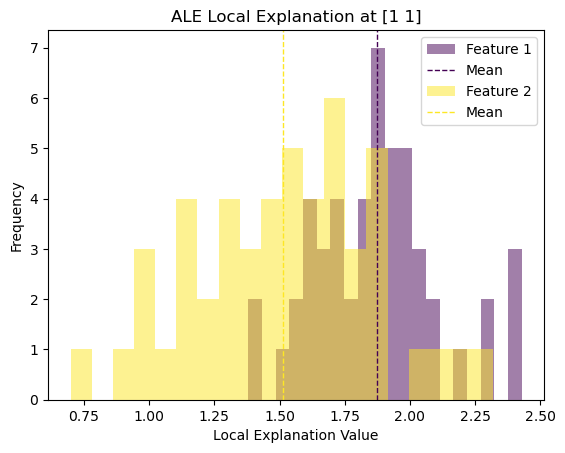

In [41]:
if run_example_5:
    plot_replicated_local_explanations(ale_replications, x_explain, method="ALE")

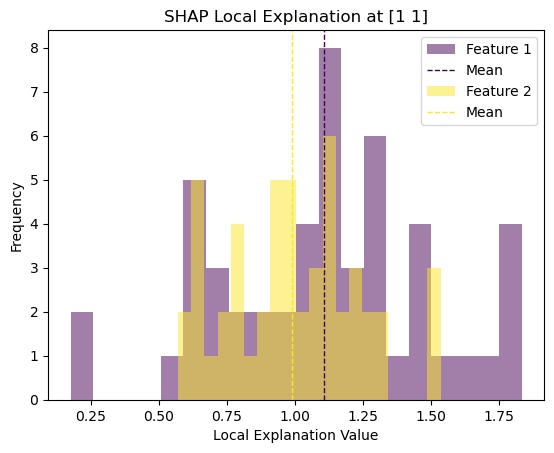

In [42]:
if run_example_5:
    plot_replicated_local_explanations(shap_replications, x_explain, method="SHAP")

7it [00:13,  1.97s/it]


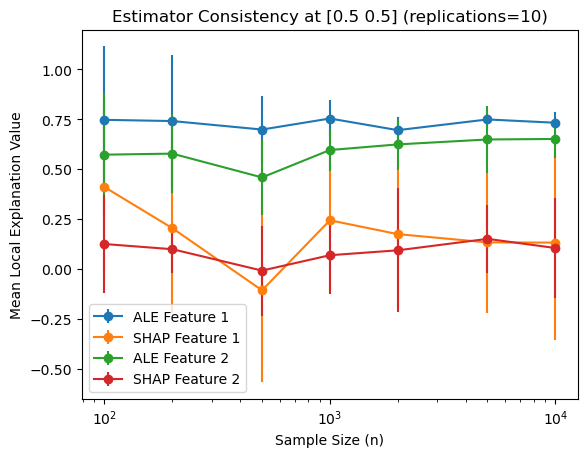

In [45]:
if run_example_5:
    plot_estimator_consistency(example_5_dgp, example_5_f_factory, np.array([0.5, 0.5]), m=10, config=config)